In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('SmallDataset.csv')
df

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17 00:00:00,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27 00:00:00,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06 00:00:00,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25 00:00:00,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06 00:00:00,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16 00:00:00,OH,500/1000,1000,1310.80,0,431289,...,1,?,87200,17440,8720,61040,Honda,Accord,2006,N
996,285,41,186934,2014-01-05 00:00:00,IL,100/300,1000,1436.79,0,608177,...,3,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N
997,130,34,918516,2003-02-17 00:00:00,OH,250/500,500,1383.49,3000000,442797,...,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N
998,458,62,533940,2011-11-18 00:00:00,IL,500/1000,2000,1356.92,5000000,441714,...,1,YES,46980,5220,5220,36540,Audi,A5,1998,N


In [3]:
df['fraud_reported'].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [4]:
df.shape

(1000, 39)

In [5]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='object')

In [6]:
#cleaning
df=df.apply(lambda x:x.replace('?',np.nan))

In [7]:
df.isnull().sum().sort_values(ascending=False)

property_damage                360
police_report_available        343
collision_type                 178
authorities_contacted           91
auto_model                       0
auto_make                        0
vehicle_claim                    0
property_claim                   0
injury_claim                     0
total_claim_amount               0
incident_severity                0
witnesses                        0
bodily_injuries                  0
auto_year                        0
number_of_vehicles_involved      0
incident_hour_of_the_day         0
incident_location                0
incident_city                    0
incident_state                   0
months_as_customer               0
age                              0
insured_zip                      0
policy_number                    0
policy_bind_date                 0
policy_state                     0
policy_csl                       0
policy_deductable                0
policy_annual_premium            0
umbrella_limit      

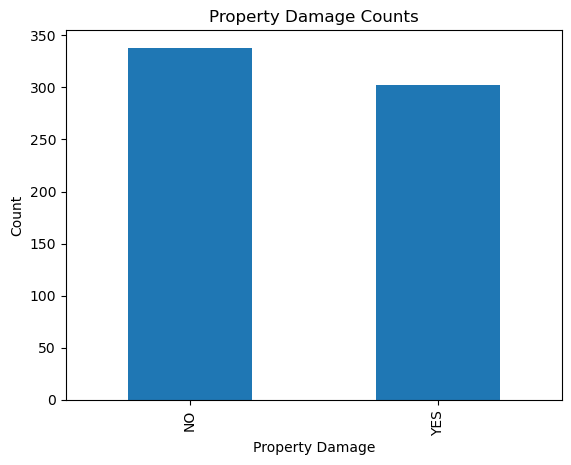

In [8]:
df['property_damage'].value_counts().plot(kind='bar')

plt.xlabel('Property Damage')
plt.ylabel('Count')
plt.title('Property Damage Counts')
plt.show()

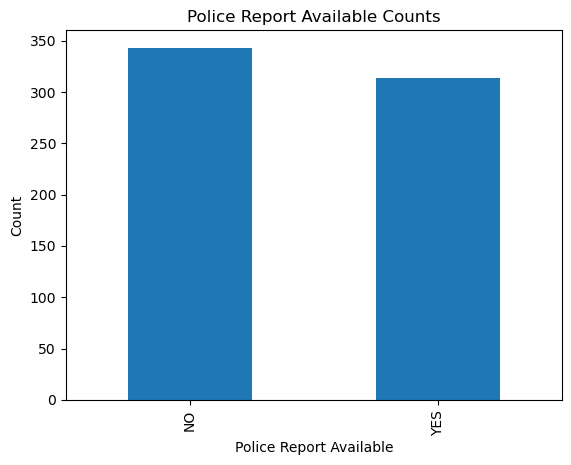

In [9]:
df['police_report_available'].value_counts().plot(kind='bar')

plt.xlabel('Police Report Available')
plt.ylabel('Count')
plt.title('Police Report Available Counts')
plt.show()

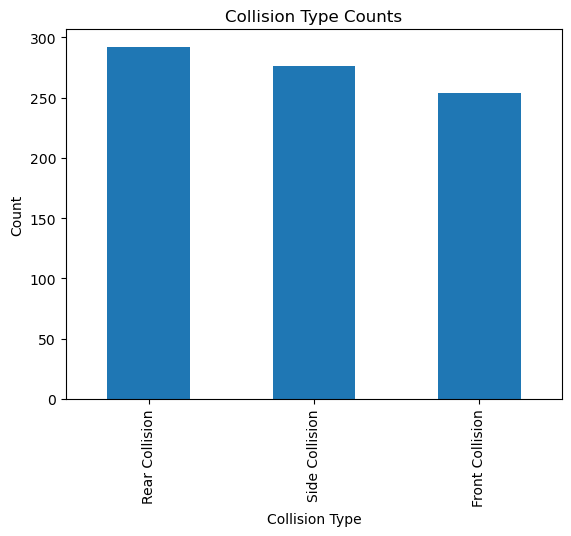

In [10]:
df['collision_type'].value_counts().plot(kind='bar')

plt.xlabel('Collision Type')
plt.ylabel('Count')
plt.title('Collision Type Counts')
plt.show()

In [11]:
from sklearn_pandas import CategoricalImputer
imp_mean= CategoricalImputer(missing_values=np.nan)
df['property_damage'] = imp_mean.fit_transform(df['property_damage'])
df['police_report_available'] = imp_mean.fit_transform(df['police_report_available'])
df['collision_type'] = imp_mean.fit_transform(df['collision_type'])
df['authorities_contacted'] = imp_mean.fit_transform(df['authorities_contacted'])

In [12]:
df.isnull().sum().sort_values(ascending=False)

months_as_customer             0
witnesses                      0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
police_report_available        0
incident_severity              0
total_claim_amount             0
injury_claim                   0
property_claim                 0
vehicle_claim                  0
auto_make                      0
auto_model                     0
auto_year                      0
authorities_contacted          0
collision_type                 0
age                            0
insured_zip                    0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_sex                    0
incident_t

In [13]:
fraud=df['fraud_reported'] == 'Y'
df_fraud = df[fraud]
df_fraud

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17 00:00:00,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27 00:00:00,IN,250/500,2000,1197.22,5000000,468176,...,0,NO,5070,780,780,3510,Mercedes,E400,2007,Y
3,256,41,227811,1990-05-25 00:00:00,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
5,256,39,104594,2006-10-12 00:00:00,OH,250/500,1000,1351.10,0,478456,...,2,NO,64100,6410,6410,51280,Saab,95,2003,Y
14,180,38,644081,1998-12-28 00:00:00,OH,250/500,2000,1301.13,0,476685,...,2,YES,46200,4200,8400,33600,Dodge,Neon,2003,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,234,41,291006,1990-05-16 00:00:00,IN,100/300,500,951.56,0,455426,...,1,NO,98280,15120,7560,75600,Chevrolet,Tahoe,2007,Y
977,266,42,929306,2003-03-06 00:00:00,IN,100/300,500,1093.83,4000000,468454,...,1,NO,53280,4440,8880,39960,Suburu,Impreza,2015,Y
982,230,43,490514,2007-02-09 00:00:00,IN,500/1000,2000,1101.83,0,451529,...,3,YES,51900,5190,10380,36330,BMW,M5,2011,Y
986,232,42,182953,2013-04-30 00:00:00,IN,100/300,500,944.03,0,440153,...,3,NO,77000,15400,7700,53900,Toyota,Highlander,2015,Y


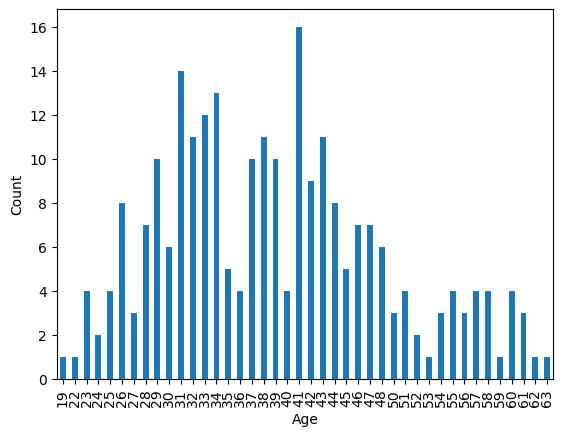

In [14]:
df_fraud['age'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [15]:
#df['policy_bind_date'] = 
df['policy_state'] = df['policy_state'].astype('category').cat.codes

df['policy_csl'].unique()
df['policy_csl'] = df['policy_csl'].replace(to_replace = '250/500', value=750)
df['policy_csl'] = df['policy_csl'].replace(to_replace = '100/300', value=400)
df['policy_csl'] = df['policy_csl'].replace(to_replace = '500/1000', value=1500)

df['insured_sex'] = df['insured_sex'].replace(to_replace = 'MALE', value=0)
df['insured_sex'] = df['insured_sex'].replace(to_replace = 'FEMALE', value=1)

df['insured_education_level'].unique()

df['insured_education_level'] = df['insured_education_level'].replace(to_replace = 'High School', value=0)
df['insured_education_level'] = df['insured_education_level'].replace(to_replace = ['College', 'Associate'], value=1)
df['insured_education_level'] = df['insured_education_level'].replace(to_replace = ['Masters', 'MD', 'JD'], value=2)
df['insured_education_level'] = df['insured_education_level'].replace(to_replace = 'PhD', value=3)

df['insured_occupation'] = df['insured_occupation'].astype('category').cat.codes
df['insured_hobbies'] = df['insured_hobbies'].astype('category').cat.codes
df['insured_relationship'] = df['insured_relationship'].astype('category').cat.codes

df['incident_date'] = df['incident_date'].str.slice(0,4).astype(int)

df['incident_type'].unique()

df['incident_type'] = df['incident_type'].replace(to_replace = ['Vehicle Theft','Parked Car'], value=0)
df['incident_type'] = df['incident_type'].replace(to_replace = 'Single Vehicle Collision', value=1)
df['incident_type'] = df['incident_type'].replace(to_replace = 'Multi-vehicle Collision', value=2)

df['collision_type'] = df['collision_type'].astype('category').cat.codes

df['incident_severity'].unique()
df['incident_severity'] = df['incident_severity'].replace(to_replace = ['Trivial Damage','Minor Damage'], value=0)
df['incident_severity'] = df['incident_severity'].replace(to_replace = 'Major Damage', value=1)
df['incident_severity'] = df['incident_severity'].replace(to_replace = 'Total Loss', value=2)

df['authorities_contacted'].unique()

df['authorities_contacted'] = df['authorities_contacted'].replace(to_replace = ['None','Other'], value=0)
df['authorities_contacted'] = df['authorities_contacted'].replace(to_replace = 'Fire', value=1)
df['authorities_contacted'] = df['authorities_contacted'].replace(to_replace = ['Police','Ambulance'], value=2)

df['incident_state'] = df['incident_state'].astype('category').cat.codes
df['incident_city'] = df['incident_city'].astype('category').cat.codes
df['auto_make'] = df['auto_make'].astype('category').cat.codes
df['auto_model'] = df['auto_model'].astype('category').cat.codes

df = df.drop('incident_location', axis=1)

df['property_damage'] = df['property_damage'].replace(to_replace = 'NO', value=0)
df['property_damage'] = df['property_damage'].replace(to_replace = 'YES', value=1)
df['police_report_available'] = df['police_report_available'].replace(to_replace = 'NO', value=0)
df['police_report_available'] = df['police_report_available'].replace(to_replace = 'YES', value=1)
df['fraud_reported'] = df['fraud_reported'].replace(to_replace = 'N', value=0)
df['fraud_reported'] = df['fraud_reported'].replace(to_replace = 'Y', value=1)



C:\Users\darag\AppData\Local\Temp\ipykernel_12856\2425225722.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['policy_csl'] = df['policy_csl'].replace(to_replace = '500/1000', value=1500)
C:\Users\darag\AppData\Local\Temp\ipykernel_12856\2425225722.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['insured_sex'] = df['insured_sex'].replace(to_replace = 'FEMALE', value=1)
C:\Users\darag\AppData\Local\Temp\ipykernel_12856\2425225722.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

In [16]:
df= df.drop('policy_number', axis= 1)
df= df.drop('incident_date', axis= 1)
df= df.drop('policy_bind_date', axis= 1)

In [17]:
df

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,2,750,1000,1406.91,0,466132,0,2,...,2,1,71610,6510,13020,52080,10,1,2004,1
1,228,42,1,750,2000,1197.22,5000000,468176,0,2,...,0,0,5070,780,780,3510,8,12,2007,1
2,134,29,2,400,2000,1413.14,5000000,430632,1,3,...,3,0,34650,7700,3850,23100,4,30,2007,0
3,256,41,0,750,2000,1415.74,6000000,608117,1,3,...,2,0,63400,6340,6340,50720,3,34,2014,1
4,228,44,0,1500,1000,1583.91,6000000,610706,0,1,...,1,0,6500,1300,650,4550,0,31,2009,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,2,1500,1000,1310.80,0,431289,1,2,...,1,0,87200,17440,8720,61040,6,6,2006,0
996,285,41,0,400,1000,1436.79,0,608177,1,3,...,3,0,108480,18080,18080,72320,13,28,2015,0
997,130,34,2,750,500,1383.49,3000000,442797,1,2,...,3,1,67500,7500,7500,52500,11,19,1996,0
998,458,62,0,1500,2000,1356.92,5000000,441714,0,1,...,1,1,46980,5220,5220,36540,1,5,1998,0


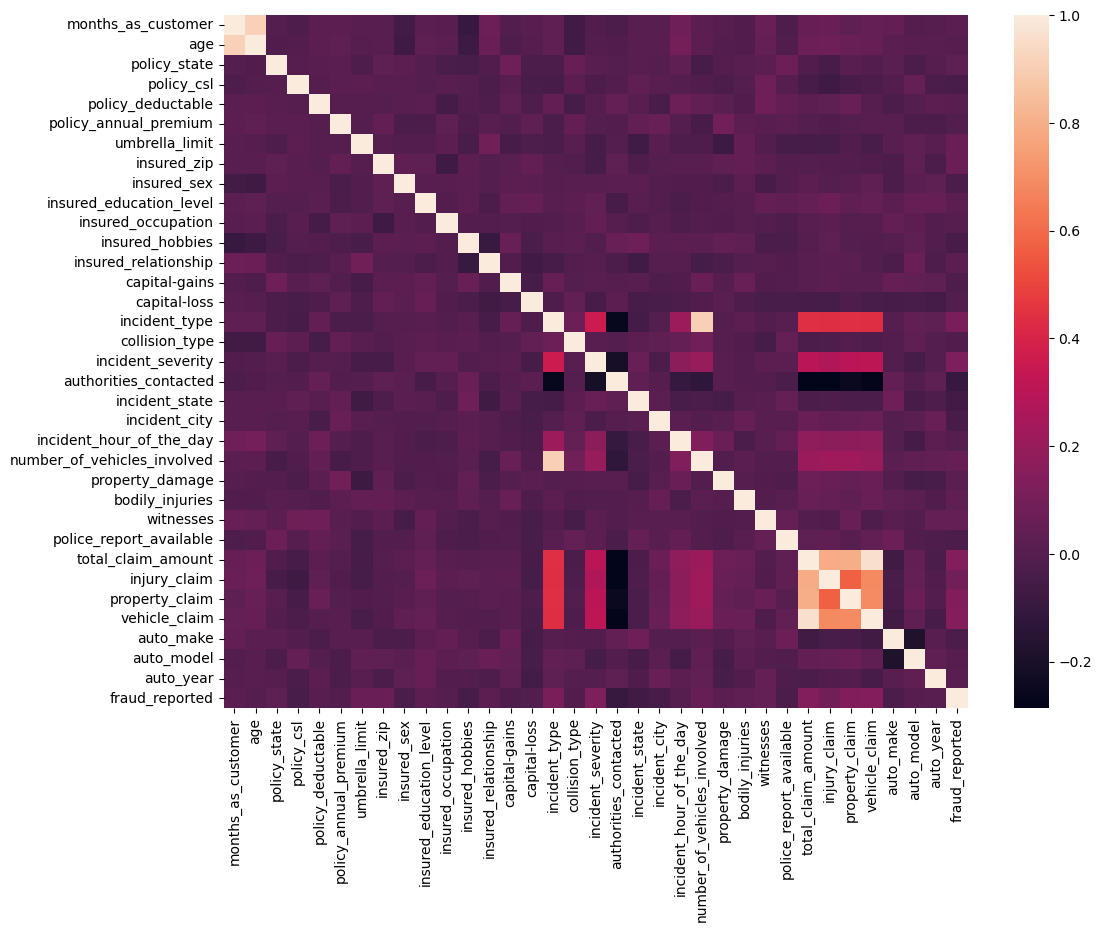

In [18]:
import seaborn as sns

corrmat = df.corr(method='spearman')
f, ax = plt.subplots(figsize=(12,9))
corrmat
sns.heatmap(corrmat, xticklabels=True, yticklabels=True);

In [20]:
df = df.drop('months_as_customer', axis=1)
df = df.drop('vehicle_claim', axis=1)
df = df.drop('injury_claim', axis=1)
df = df.drop('property_claim', axis=1)

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U3'), dtype('<U3')) -> None

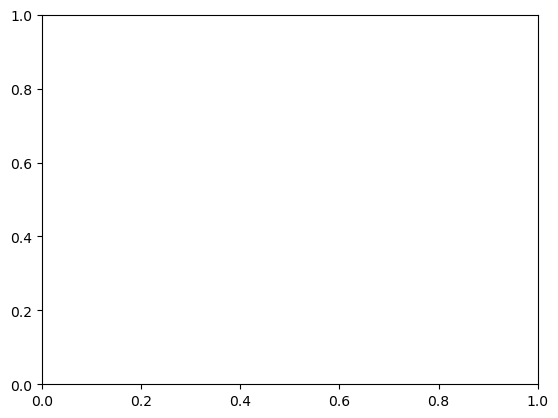

In [35]:
for col in df.columns:
    #print(col)
    plt.figure()
    plt.boxplot([col])

In [22]:
df = df[df.policy_annual_premium>600]
df = df[df.policy_annual_premium<1900]

In [23]:
df = df.drop('umbrella_limit', axis = 1)

In [24]:
df

,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,...,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported
0,48,2,750,1000,1406.91,466132,0,2,2,17,...,1,1,1,2,1,71610,10,1,2004,1
1,42,1,750,2000,1197.22,468176,0,2,6,15,...,1,0,0,0,0,5070,8,12,2007,1
2,29,2,400,2000,1413.14,430632,1,3,11,2,...,3,0,2,3,0,34650,4,30,2007,0
3,41,0,750,2000,1415.74,608117,1,3,1,2,...,1,0,1,2,0,63400,3,34,2014,1
4,44,0,1500,1000,1583.91,610706,0,1,11,2,...,1,0,0,1,0,6500,0,31,2009,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,38,2,1500,1000,1310.80,431289,1,2,2,13,...,1,1,0,1,0,87200,6,6,2006,0
996,41,0,400,1000,1436.79,608177,1,3,9,17,...,1,1,2,3,0,108480,13,28,2015,0
997,34,2,750,500,1383.49,442797,1,2,1,3,...,3,0,2,3,1,67500,11,19,1996,0
998,62,0,1500,2000,1356.92,441714,0,1,5,0,...,1,0,0,1,1,46980,1,5,1998,0


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df=pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df

,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,...,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported
0,0.644444,1.0,0.318182,0.333333,0.617128,0.188769,0.0,0.666667,0.153846,0.894737,...,0.000000,1.0,0.5,0.666667,1.0,0.622801,0.769231,0.026316,0.45,1.0
1,0.511111,0.5,0.318182,1.000000,0.453282,0.199478,0.0,0.666667,0.461538,0.789474,...,0.000000,0.0,0.0,0.000000,0.0,0.043285,0.615385,0.315789,0.60,1.0
2,0.222222,1.0,0.000000,1.000000,0.621996,0.002766,1.0,1.000000,0.846154,0.105263,...,0.666667,0.0,1.0,1.000000,0.0,0.300906,0.307692,0.789474,0.60,0.0
3,0.488889,0.0,0.318182,1.000000,0.624027,0.932699,1.0,1.000000,0.076923,0.105263,...,0.000000,0.0,0.5,0.666667,0.0,0.551298,0.230769,0.894737,0.95,1.0
4,0.555556,0.0,1.000000,0.333333,0.755431,0.946264,0.0,0.333333,0.846154,0.105263,...,0.000000,0.0,0.0,0.333333,0.0,0.055739,0.000000,0.815789,0.70,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,0.422222,1.0,1.000000,0.333333,0.542030,0.006209,1.0,0.666667,0.153846,0.684211,...,0.000000,1.0,0.0,0.333333,0.0,0.758579,0.461538,0.157895,0.55,0.0
987,0.488889,0.0,0.000000,0.333333,0.640475,0.933013,1.0,1.000000,0.692308,0.894737,...,0.000000,1.0,1.0,1.000000,0.0,0.943912,1.000000,0.736842,1.00,0.0
988,0.333333,1.0,0.318182,0.000000,0.598828,0.066505,1.0,0.666667,0.076923,0.157895,...,0.666667,0.0,1.0,1.000000,1.0,0.587006,0.846154,0.500000,0.05,0.0
989,0.955556,0.0,1.000000,1.000000,0.578067,0.060831,0.0,0.333333,0.384615,0.000000,...,0.000000,0.0,0.0,0.333333,1.0,0.408291,0.076923,0.131579,0.15,0.0


In [33]:
y = df['fraud_reported']
x = df.drop('fraud_reported', axis = 1)

import sklearn.model_selection as model_selection
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,y,train_size=0.7, test_size=0.3, random_state=101)

In [37]:
from sklearn.metrics import accuracy_score, log_loss, f1_score, recall_score, precision_score, classification_report, confusion_matrix
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

classifiers = [
    LogisticRegression(),
    Perceptron(max_iter=1000, tol= 1e-3),
    MLPClassifier(hidden_layer_sizes=(10,10,10), max_iter=1000)
]

log_cols=['Classifier','Accuracy','Log Loss']
log = pd.DataFrame(columns=log_cols)

In [38]:
accuracy = []
f1_sc = []
recall = []
precision = []
#loss = []

for clf in classifiers:
    clf.fit(x_train, y_train)
    name = clf.__class__.__name__
    print('='*30)
    print(name)

    print('****Results****')
    train_predictions = clf.predict(x_test)

    acc = accuracy_score(y_test, train_predictions)
    print('Accuracy: {:.4%}'.format(acc))
    accuracy.append(acc)

    f1= f1_score(y_test, train_predictions, average='weighted')
    print('F1 score: {:.4%}'.format(f1))
    f1_sc.append(f1)

    recall_sc= recall_score(y_test, train_predictions, average='weighted')
    print('Recall: {:.4%}'.format(recall_sc))
    f1_sc.append(recall_sc)

    pr_score= precision_score(y_test, train_predictions, average='weighted')
    print('Precision: {:.4%}'.format(pr_score))
    f1_sc.append(pr_score)

    print('Confusion Matrix')
    print('-'*30)
    print(confusion_matrix(y_test, train_predictions))
    print('Classification report')
    print(classification_report(y_test, train_predictions))

print('='*30)

LogisticRegression
****Results****
Accuracy: 76.5101%
F1 score: 66.9099%
Recall: 76.5101%
Precision: 59.4504%
Confusion Matrix
------------------------------
[[228   2]
 [ 68   0]]
Classification report
              precision    recall  f1-score   support

         0.0       0.77      0.99      0.87       230
         1.0       0.00      0.00      0.00        68

    accuracy                           0.77       298
   macro avg       0.39      0.50      0.43       298
weighted avg       0.59      0.77      0.67       298

Perceptron
****Results****
Accuracy: 77.1812%
F1 score: 67.2412%
Recall: 77.1812%
Precision: 59.5694%
Confusion Matrix
------------------------------
[[230   0]
 [ 68   0]]
Classification report
              precision    recall  f1-score   support

         0.0       0.77      1.00      0.87       230
         1.0       0.00      0.00      0.00        68

    accuracy                           0.77       298
   macro avg       0.39      0.50      0.44       298
wei

C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C

MLPClassifier
****Results****
Accuracy: 77.5168%
F1 score: 77.4579%
Recall: 77.5168%
Precision: 77.4009%
Confusion Matrix
------------------------------
[[197  33]
 [ 34  34]]
Classification report
              precision    recall  f1-score   support

         0.0       0.85      0.86      0.85       230
         1.0       0.51      0.50      0.50        68

    accuracy                           0.78       298
   macro avg       0.68      0.68      0.68       298
weighted avg       0.77      0.78      0.77       298

